# Klasifikasi Kualitas Udara DKI Jakarta Berdasarkan Data Sensor Polutan Menggunakan Algoritma Machine Learning
## Implementasi & Perbandingan KNN, SVM, dan Random Forest

---

**Mata Kuliah:** Pembelajaran Mesin (IF2514403)  
**Kelompok:** 07  
**Anggota:**
- Alisya Duri Azizah (11241011)
- Lisa Sapitri (11241041)
- Mutia Rahmawati (11241065)
- Veronika Thalila Putri (11241087)

**Paper Referensi:** *Perbandingan KNN dan SVM untuk Klasifikasi Kualitas Udara di Jakarta* — Bryan Valentino Jayadi, Teny Handhayani, PhD., Manatap Dolok Lauro (Universitas Tarumanagara)  
**Dataset yang Digunakan:** `dataset_ispu_jakarta.csv` (Dataset ISPU DKI Jakarta)




## Import Library


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Model Klasifikasi ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Preprocessing & Split ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Hyperparameter Tuning ---
from sklearn.model_selection import GridSearchCV
import time

# --- Evaluasi ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)


## Load Dataset



In [3]:

df = pd.read_csv('dataset_ispu_jakarta.csv')

print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'Nama kolom: {df.columns.tolist()}')
df.head()


Jumlah baris: 3501
Jumlah kolom: 13
Nama kolom: ['periode_data', 'bulan', 'tanggal', 'stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'parameter_pencemar_kritis', 'kategori']


,periode_data,bulan,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,parameter_pencemar_kritis,kategori
0,202401,1,21,DKI3 JAGAKARSA,51.0,65.0,45.0,9.0,8.0,79.0,79.0,NaN,SEDANG
1,202401,1,22,DKI3 JAGAKARSA,27.0,34.0,45.0,5.0,8.0,56.0,56.0,NaN,SEDANG
2,202401,1,23,DKI3 JAGAKARSA,NaN,52.0,46.0,6.0,9.0,51.0,52.0,PM25,SEDANG
3,202401,1,24,DKI3 JAGAKARSA,46.0,65.0,46.0,8.0,9.0,38.0,65.0,PM25,SEDANG
4,202401,1,25,DKI3 JAGAKARSA,37.0,55.0,47.0,7.0,11.0,28.0,55.0,PM25,SEDANG


In [5]:
print('Informasi Dataset')
df.info()

print('Statistik Deskriptif')
df.describe().round(2)


Informasi Dataset
<class 'pandas.DataFrame'>
RangeIndex: 3501 entries, 0 to 3500
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   periode_data               3501 non-null   int64  
 1   bulan                      3501 non-null   int64  
 2   tanggal                    3501 non-null   int64  
 3   stasiun                    3501 non-null   str    
 4   pm10                       3237 non-null   float64
 5   pm25                       3440 non-null   float64
 6   so2                        3445 non-null   float64
 7   co                         3451 non-null   float64
 8   o3                         3455 non-null   float64
 9   no2                        3432 non-null   float64
 10  max                        3493 non-null   float64
 11  parameter_pencemar_kritis  3436 non-null   str    
 12  kategori                   3500 non-null   str    
dtypes: float64(7), int64(3), str(3)
memory us

,periode_data,bulan,tanggal,pm10,pm25,so2,co,o3,no2,max
count,3501.00,3501.00,3501.00,3237.00,3440.00,3445.00,3451.00,3455.00,3432.00,3493.00
mean,202454.01,6.28,15.73,48.88,71.40,36.03,15.10,23.79,27.21,73.09
std,49.82,3.32,8.80,16.55,23.21,15.88,6.83,12.80,16.67,21.41
min,202401.00,1.00,1.00,5.00,10.00,3.00,2.00,2.00,1.00,0.00
25%,202406.00,3.00,8.00,37.00,56.00,24.00,10.00,15.00,15.00,58.00
50%,202412.00,6.00,16.00,52.00,73.00,32.00,14.00,21.00,23.00,73.00
75%,202506.00,9.00,23.00,60.00,87.00,53.00,20.00,29.00,37.00,87.00
max,202511.00,12.00,31.00,187.00,157.00,112.00,70.00,115.00,202.00,202.00


In [6]:
print('Jumlah Nilai Kosong (Missing Value)')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pd.DataFrame({'Jumlah Kosong': missing, 'Persentase (%)': missing_pct}))

Jumlah Nilai Kosong (Missing Value)
                           Jumlah Kosong  Persentase (%)
periode_data                           0            0.00
bulan                                  0            0.00
tanggal                                0            0.00
stasiun                                0            0.00
pm10                                 264            7.54
pm25                                  61            1.74
so2                                   56            1.60
co                                    50            1.43
o3                                    46            1.31
no2                                   69            1.97
max                                    8            0.23
parameter_pencemar_kritis             65            1.86
kategori                               1            0.03


## Eksplorasi Data (EDA)


In [7]:
print('=== Distribusi Lengkap Kolom kategori ===')
print(df['kategori'].value_counts())


=== Distribusi Lengkap Kolom kategori ===
kategori
SEDANG                2694
BAIK                   444
TIDAK SEHAT            341
TIDAK ADA DATA          20
SANGAT TIDAK SEHAT       1
Name: count, dtype: int64


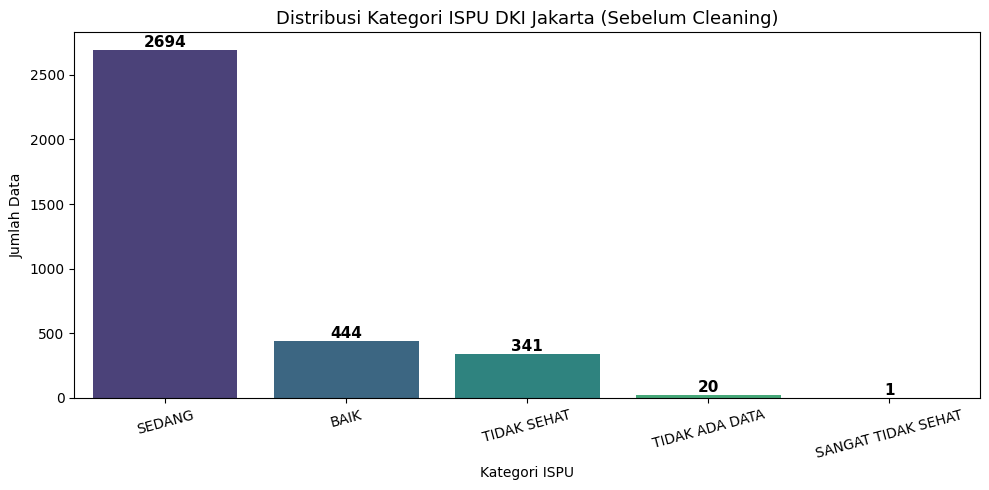

In [8]:
plt.figure(figsize=(10, 5))
order = df['kategori'].value_counts().index
ax = sns.countplot(x='kategori', data=df, order=order,
                   palette='viridis')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Distribusi Kategori ISPU DKI Jakarta (Sebelum Cleaning)', fontsize=13)
plt.xlabel('Kategori ISPU')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [9]:
fitur_polutan_raw = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']
print('Statistik Deskriptif Fitur Polutan ')
df[fitur_polutan_raw].describe().round(2)


Statistik Deskriptif Fitur Polutan 


,pm25,pm10,so2,co,o3,no2
count,3440.00,3237.00,3445.00,3451.00,3455.00,3432.00
mean,71.40,48.88,36.03,15.10,23.79,27.21
std,23.21,16.55,15.88,6.83,12.80,16.67
min,10.00,5.00,3.00,2.00,2.00,1.00
25%,56.00,37.00,24.00,10.00,15.00,15.00
50%,73.00,52.00,32.00,14.00,21.00,23.00
75%,87.00,60.00,53.00,20.00,29.00,37.00
max,157.00,187.00,112.00,70.00,115.00,202.00


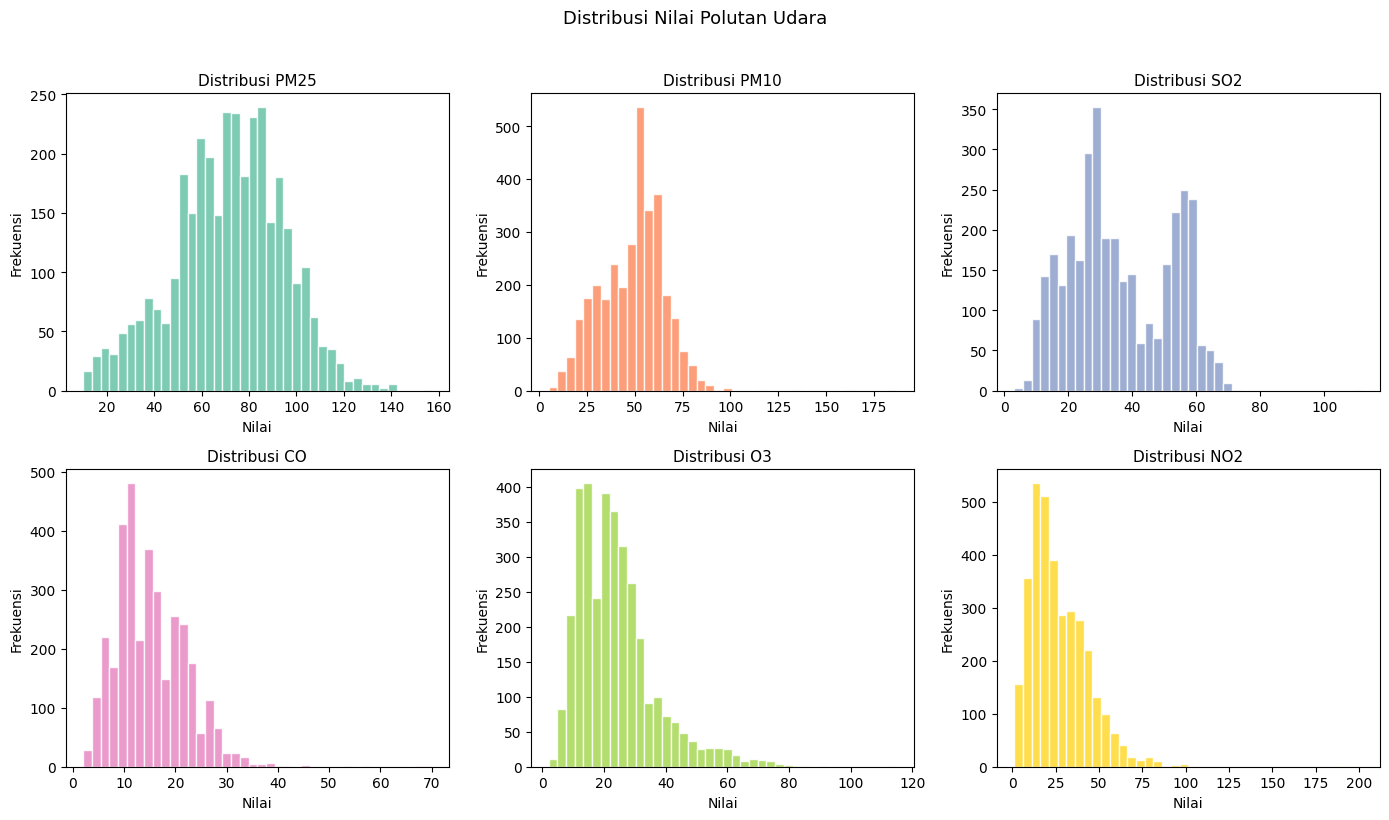

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
all_features = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']
colors = sns.color_palette('Set2', 6)

for i, (col, color) in enumerate(zip(all_features, colors)):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col].dropna(), bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribusi {col.upper()}', fontsize=11)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Nilai Polutan Udara', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## EDA Lanjutan

korelasi heatmap 

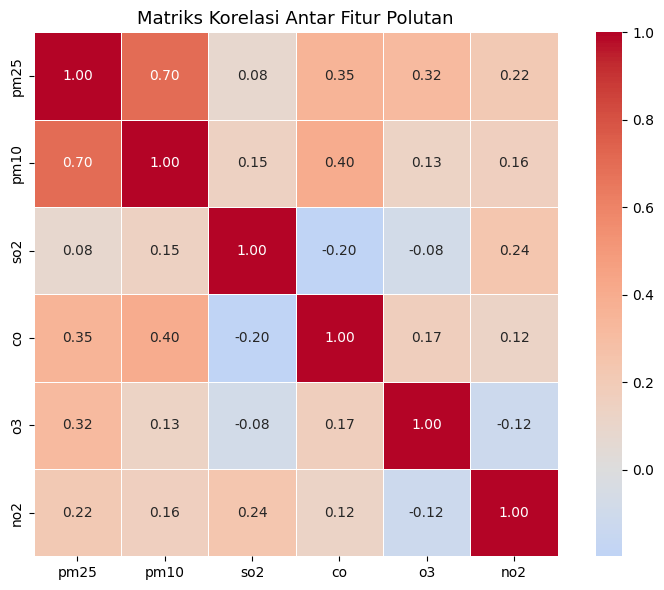

In [12]:
plt.figure(figsize=(8, 6))
corr_matrix = df[['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']].corr()

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    center = 0,
    linewidths = 0.5,
    square = True
)
plt.title('Matriks Korelasi Antar Fitur Polutan', fontsize=13)
plt.tight_layout()
plt.show()

## Preprocessing Data (Pembersihan Data)



In [14]:
valid_labels = ['BAIK', 'SEDANG', 'TIDAK SEHAT']
df_clean = df[df['kategori'].isin(valid_labels)].copy()

print(f'Baris sebelum filter : {len(df)}')
print(f'Baris setelah filter  : {len(df_clean)}')
print(f'Dihapus               : {len(df) - len(df_clean)} baris')
print()
print('Distribusi kelas setelah filter:')
print(df_clean['kategori'].value_counts())


Baris sebelum filter : 3501
Baris setelah filter  : 3479
Dihapus               : 22 baris

Distribusi kelas setelah filter:
kategori
SEDANG         2694
BAIK            444
TIDAK SEHAT     341
Name: count, dtype: int64


In [15]:
cols_to_drop = ['periode_data', 'bulan', 'tanggal', 'stasiun', 'parameter_pencemar_kritis', 'max']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

print('Kolom yang tersisa:', df_clean.columns.tolist())


Kolom yang tersisa: ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'kategori']


In [16]:
fitur_polutan = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']

print('Missing value SEBELUM interpolasi:')
print(df_clean[fitur_polutan].isnull().sum())

df_clean = df_clean.sort_values(['kategori']).reset_index(drop=True)
for col in fitur_polutan:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')

print('\nMissing value SETELAH interpolasi:')
print(df_clean[fitur_polutan].isnull().sum())



Missing value SEBELUM interpolasi:
pm25     40
pm10    243
so2      35
co       29
o3       25
no2      48
dtype: int64

Missing value SETELAH interpolasi:
pm25    0
pm10    0
so2     0
co      0
o3      0
no2     0
dtype: int64


In [17]:
print(f'Jumlah duplikat ditemukan: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Ukuran data setelah cleaning: {df_clean.shape}')

print('\nDistribusi label setelah cleaning:')
print(df_clean['kategori'].value_counts())

Jumlah duplikat ditemukan: 10
Ukuran data setelah cleaning: (3469, 7)

Distribusi label setelah cleaning:
kategori
SEDANG         2686
BAIK            442
TIDAK SEHAT     341
Name: count, dtype: int64


## Transformasi Data (Encoding & Scaling)


In [18]:
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['kategori'])

print('=== Mapping Label Encoding ===')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls:25s} → {idx}')


=== Mapping Label Encoding ===
  BAIK                      → 0
  SEDANG                    → 1
  TIDAK SEHAT               → 2


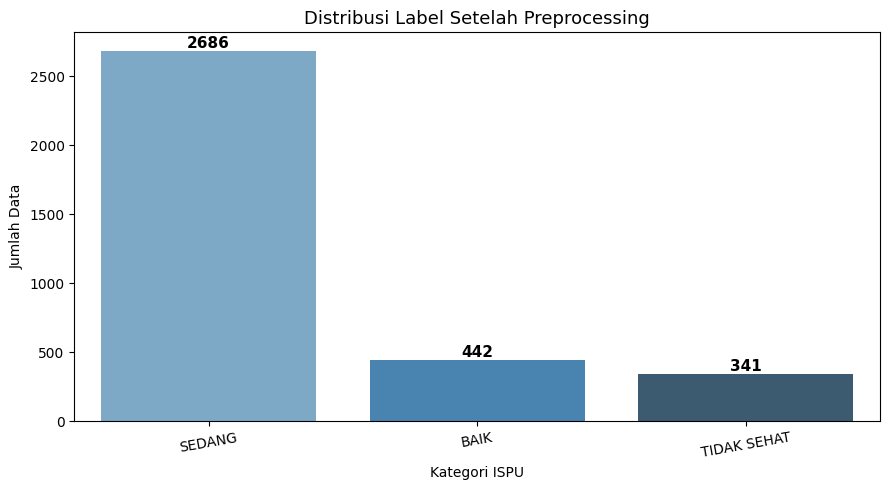

In [19]:
dist_clean = df_clean['kategori'].value_counts()

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=dist_clean.index, y=dist_clean.values,
                 palette='Blues_d', order=dist_clean.index)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Distribusi Label Setelah Preprocessing', fontsize=13)
plt.xlabel('Kategori ISPU')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## Pemisahan Data (Train-Test Split)


In [20]:
fitur_dipakai = [f for f in fitur_polutan if f in df_clean.columns]
X = df_clean[fitur_dipakai].values
y = df_clean['label'].values

print(f'Fitur yang digunakan : {fitur_dipakai}')
print(f'Shape X (fitur)      : {X.shape}  ← ({X.shape[0]} sampel, {X.shape[1]} fitur polutan)')
print(f'Shape y (label)      : {y.shape}')

Fitur yang digunakan : ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']
Shape X (fitur)      : (3469, 6)  ← (3469 sampel, 6 fitur polutan)
Shape y (label)      : (3469,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)        

print(f'Data latih  : {X_train.shape[0]} sampel')
print(f'Data uji    : {X_test.shape[0]} sampel')


Data latih  : 2775 sampel
Data uji    : 694 sampel



## Pemodelan Algoritma Klasifikasi


## Pelatihan Model & Evaluasi

In [22]:
# model 1 : KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print('=== Evaluasi KNN ===')
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

=== Evaluasi KNN ===
              precision    recall  f1-score   support

        BAIK       0.89      0.82      0.85        89
      SEDANG       0.95      0.97      0.96       537
 TIDAK SEHAT       0.92      0.85      0.89        68

    accuracy                           0.94       694
   macro avg       0.92      0.88      0.90       694
weighted avg       0.94      0.94      0.94       694



In [23]:
# model 2 : SVM
svm = SVC(kernel='rbf', C=100, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print('=== Evaluasi SVM ===')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

=== Evaluasi SVM ===
              precision    recall  f1-score   support

        BAIK       0.91      0.88      0.89        89
      SEDANG       0.98      0.98      0.98       537
 TIDAK SEHAT       0.93      0.97      0.95        68

    accuracy                           0.96       694
   macro avg       0.94      0.94      0.94       694
weighted avg       0.96      0.96      0.96       694



In [24]:
# model 3 : Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print('=== Evaluasi Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Evaluasi Random Forest ===
              precision    recall  f1-score   support

        BAIK       0.96      0.96      0.96        89
      SEDANG       0.99      0.99      0.99       537
 TIDAK SEHAT       1.00      0.99      0.99        68

    accuracy                           0.99       694
   macro avg       0.98      0.98      0.98       694
weighted avg       0.99      0.99      0.99       694



In [25]:
def hitung_metrik(y_true, y_pred, nama_model):
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='weighted') * 100
    rec = recall_score(y_true, y_pred, average='weighted') * 100
    f1 = f1_score(y_true, y_pred, average='weighted') * 100
    return {
        'Model': nama_model,
        'Akurasi (%)': round(acc, 2),
        'Presisi (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2)
    }

hasil = [
    hitung_metrik(y_test, y_pred_knn, 'KNN'),
    hitung_metrik(y_test, y_pred_svm, 'SVM'),
    hitung_metrik(y_test, y_pred_rf, 'Random Forest')
]



In [26]:
# Tabel ringkasan hasil
hasil_df = pd.DataFrame(hasil).set_index('Model')
print('=== TABEL PERBANDINGAN HASIL SEMUA MODEL ===')
hasil_df



=== TABEL PERBANDINGAN HASIL SEMUA MODEL ===


,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
Model,,,,
KNN,94.24,94.15,94.24,94.15
SVM,96.25,96.24,96.25,96.24
Random Forest,98.70,98.70,98.70,98.70


In [27]:
best_model = hasil_df['F1-Score (%)'].idxmax()
print(f'\nModel terbaik berdasarkan F1-Score: {best_model}')


Model terbaik berdasarkan F1-Score: Random Forest


## Hyperparameter tuning

In [28]:
print('=== Tuning Hyperparameter KNN ===')

param_grid_knn = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

start = time.time()
grid_knn.fit(X_train_scaled, y_train)
print(f'Waktu tuning KNN: {time.time() - start:.2f} detik')

results_knn = pd.DataFrame(grid_knn.cv_results_)
kolom = ['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score', 'std_test_score', 'rank_test_score']
tabel_knn = results_knn[kolom].copy()
tabel_knn['mean_test_score'] = (tabel_knn['mean_test_score'] * 100).round(2)
tabel_knn['std_test_score'] = (tabel_knn['std_test_score'] * 100).round(2)
tabel_knn.columns = ['n_neighbors', 'weights', 'metric', 'F1-Score (%)', 'Std (%)', 'Rank']
tabel_knn = tabel_knn.sort_values('Rank').reset_index(drop=True)

print('kombinasi parameter KNN')
display(tabel_knn.head(10))

print(f'Best KNN: {grid_knn.best_params_} dengan F1-Score: {grid_knn.best_score_ * 100:.2f}%')
print(f'akurasi KNN: {accuracy_score(y_test, grid_knn.best_estimator_.predict(X_test_scaled)) * 100:.2f}%')

y_pred_knn_tuned = grid_knn.best_estimator_.predict(X_test_scaled)
print('=== Evaluasi KNN Tuning ===')
print(classification_report(y_test, y_pred_knn_tuned, target_names=le.classes_))

=== Tuning Hyperparameter KNN ===
Waktu tuning KNN: 5.03 detik
kombinasi parameter KNN


,n_neighbors,weights,metric,F1-Score (%),Std (%),Rank
0,4,distance,manhattan,93.23,0.92,1
1,7,distance,manhattan,93.10,0.78,2
2,6,distance,manhattan,92.98,0.85,3
3,7,uniform,manhattan,92.87,0.66,4
4,5,distance,manhattan,92.87,1.02,5
5,4,distance,minkowski,92.85,1.00,6
6,4,distance,euclidean,92.85,1.00,6
7,5,uniform,manhattan,92.85,0.94,8
8,10,distance,manhattan,92.80,1.09,9
9,3,distance,manhattan,92.74,0.93,10


Best KNN: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'} dengan F1-Score: 93.23%
akurasi KNN: 94.24%
=== Evaluasi KNN Tuning ===
              precision    recall  f1-score   support

        BAIK       0.86      0.81      0.83        89
      SEDANG       0.95      0.97      0.96       537
 TIDAK SEHAT       0.95      0.88      0.92        68

    accuracy                           0.94       694
   macro avg       0.92      0.89      0.90       694
weighted avg       0.94      0.94      0.94       694



In [29]:
print('===  Tuning Hyperparameter SVM ===')

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

start = time.time()
grid_svm.fit(X_train_scaled, y_train)
print(f'Waktu tuning SVM: {time.time() - start:.2f} detik')

results_svm = pd.DataFrame(grid_svm.cv_results_)
kolom_svm = ['param_C', 'param_kernel', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']
tabel_svm = results_svm[kolom_svm].copy()
tabel_svm['mean_test_score'] = (tabel_svm['mean_test_score'] * 100).round(2)
tabel_svm['std_test_score'] = (tabel_svm['std_test_score'] * 100).round(2)
tabel_svm.columns = ['C', 'kernel', 'gamma', 'F1-Score (%)', 'Std (%)', 'Rank']
tabel_svm = tabel_svm.sort_values('Rank').reset_index(drop=True)

print('kombinasi parameter SVM')
display(tabel_svm.head(10))

print(f'Best SVM: {grid_svm.best_params_} dengan F1-Score: {grid_svm.best_score_ * 100:.2f}%')
print(f'akurasi SVM: {accuracy_score(y_test, grid_svm.best_estimator_.predict(X_test_scaled)) * 100:.2f}%')

y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_test_scaled)
print('=== Evaluasi SVM Tuning ===')
print(classification_report(y_test, y_pred_svm_tuned, target_names=le.classes_))

===  Tuning Hyperparameter SVM ===
Waktu tuning SVM: 2.72 detik
kombinasi parameter SVM


,C,kernel,gamma,F1-Score (%),Std (%),Rank
0,100.0,rbf,auto,96.64,0.91,1
1,10.0,rbf,scale,96.60,0.59,2
2,100.0,rbf,scale,96.57,0.92,3
3,10.0,rbf,auto,96.56,0.56,4
4,100.0,rbf,0.01,96.43,0.41,5
5,100.0,poly,auto,95.60,1.00,6
6,100.0,poly,scale,95.60,1.01,7
7,1.0,rbf,scale,95.42,0.69,8
8,1.0,rbf,auto,95.38,0.76,9
9,10.0,poly,auto,95.23,0.62,10


Best SVM: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'} dengan F1-Score: 96.64%
akurasi SVM: 96.25%
=== Evaluasi SVM Tuning ===
              precision    recall  f1-score   support

        BAIK       0.91      0.88      0.89        89
      SEDANG       0.98      0.98      0.98       537
 TIDAK SEHAT       0.93      0.97      0.95        68

    accuracy                           0.96       694
   macro avg       0.94      0.94      0.94       694
weighted avg       0.96      0.96      0.96       694



In [30]:
print(' === Tuning Hyperparameter Random Forest ===')

param_grid_rf = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

start = time.time()
grid_rf.fit(X_train_scaled, y_train)
print(f'Waktu tuning Random Forest: {time.time() - start:.2f} detik')
results_rf = pd.DataFrame(grid_rf.cv_results_)
kolom_rf = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
             'mean_test_score', 'std_test_score', 'rank_test_score']
tabel_rf = results_rf[kolom_rf].copy()
tabel_rf['mean_test_score'] = (tabel_rf['mean_test_score'] * 100).round(2)
tabel_rf['std_test_score'] = (tabel_rf['std_test_score'] * 100).round(2)
tabel_rf.columns = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf',
                    'F1-Score (%)', 'Std (%)', 'Rank']
tabel_rf = tabel_rf.sort_values('Rank').reset_index(drop=True)
print('kombinasi parameter Random Forest')
display(tabel_rf.head(10))
print(f'Best Random Forest: {grid_rf.best_params_} dengan F1-Score: {grid_rf.best_score_ * 100:.2f}%')
print(f'akurasi Random Forest: {accuracy_score(y_test, grid_rf.best_estimator_.predict(X_test_scaled)) * 100:.2f}%')

y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test_scaled)
print('=== Evaluasi Random Forest Tuning ===')
print(classification_report(y_test, y_pred_rf_tuned, target_names=le.classes_))

 === Tuning Hyperparameter Random Forest ===
Waktu tuning Random Forest: 112.92 detik
kombinasi parameter Random Forest


,n_estimators,max_depth,min_samples_split,min_samples_leaf,F1-Score (%),Std (%),Rank
0,200,None,10,2,98.80,0.59,1
1,150,None,10,2,98.80,0.59,1
2,150,10,10,2,98.80,0.59,1
3,150,20,10,2,98.80,0.59,1
4,200,30,10,2,98.80,0.59,1
5,150,30,10,2,98.80,0.59,1
6,200,20,10,2,98.80,0.59,1
7,250,10,10,4,98.80,0.59,8
8,200,10,10,4,98.80,0.59,8
9,100,20,10,1,98.77,0.50,10


Best Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150} dengan F1-Score: 98.80%
akurasi Random Forest: 99.14%
=== Evaluasi Random Forest Tuning ===
              precision    recall  f1-score   support

        BAIK       0.99      0.96      0.97        89
      SEDANG       0.99      1.00      0.99       537
 TIDAK SEHAT       1.00      0.99      0.99        68

    accuracy                           0.99       694
   macro avg       0.99      0.98      0.99       694
weighted avg       0.99      0.99      0.99       694



## Baseline vs Tuned

In [31]:
hasil_lengkap = [
    hitung_metrik(y_test, y_pred_knn,       'KNN Baseline'),
    hitung_metrik(y_test, y_pred_knn_tuned, 'KNN Tuned'),
    hitung_metrik(y_test, y_pred_svm,       'SVM Baseline'),
    hitung_metrik(y_test, y_pred_svm_tuned, 'SVM Tuned'),
    hitung_metrik(y_test, y_pred_rf,        'RF Baseline'),
    hitung_metrik(y_test, y_pred_rf_tuned,  'RF Tuned'),
]

hasil_lengkap_df = pd.DataFrame(hasil_lengkap).set_index('Model')
print('=== TABEL PERBANDINGAN BASELINE vs TUNED ===')
hasil_lengkap_df

=== TABEL PERBANDINGAN BASELINE vs TUNED ===


,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
Model,,,,
KNN Baseline,94.24,94.15,94.24,94.15
KNN Tuned,94.24,94.16,94.24,94.17
SVM Baseline,96.25,96.24,96.25,96.24
SVM Tuned,96.25,96.24,96.25,96.24
RF Baseline,98.70,98.70,98.70,98.70
RF Tuned,99.14,99.14,99.14,99.13


## Confusion Matrix untuk model tuned

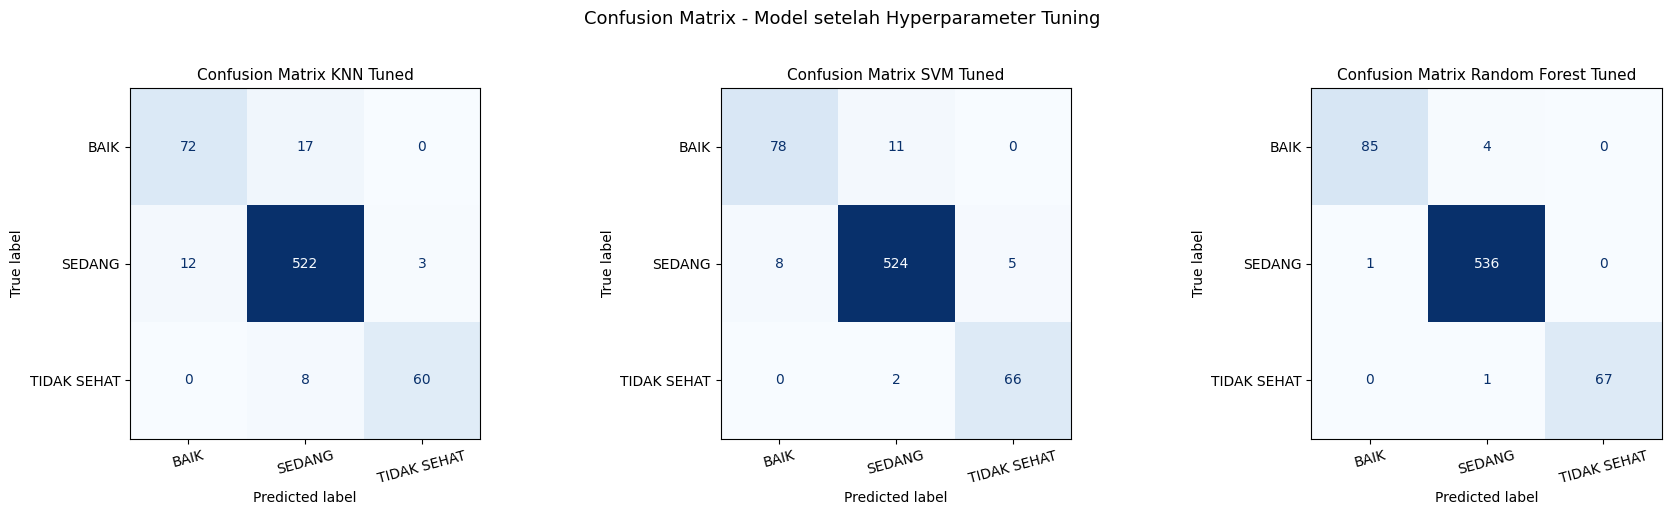

In [32]:
tuned_models = {
    'KNN': (grid_knn.best_estimator_, y_pred_knn_tuned),
    'SVM': (grid_svm.best_estimator_, y_pred_svm_tuned),
    'Random Forest': (grid_rf.best_estimator_, y_pred_rf_tuned)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nama, (model, y_pred)) in zip(axes, tuned_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix {nama} Tuned', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrix - Model setelah Hyperparameter Tuning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance Random Forest

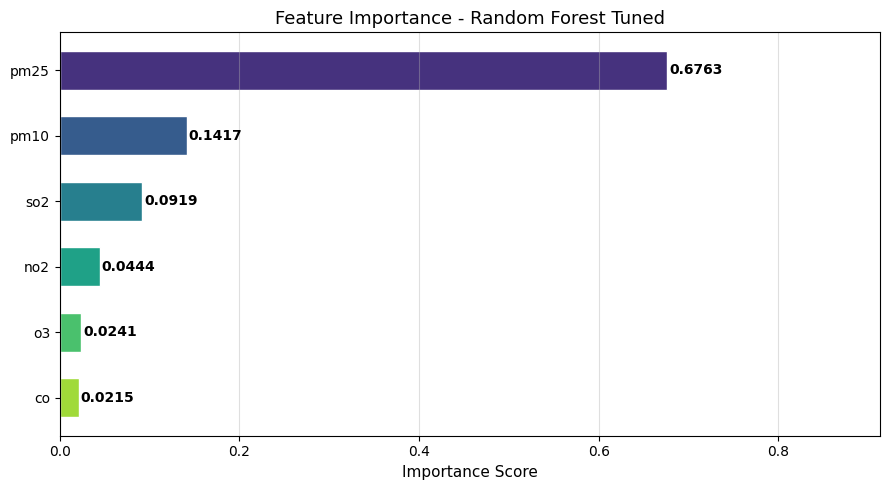

=== TABEL FEATURE IMPORTANCE ===


,Fitur,Importance Score,Kontribusi (%),Kumulatif (%)
0,pm25,0.676315,67.63,67.63
1,pm10,0.141679,14.17,81.80
2,so2,0.091924,9.19,90.99
3,no2,0.044436,4.44,95.44
4,o3,0.024113,2.41,97.85
5,co,0.021533,2.15,100.00


In [33]:
best_rf = grid_rf.best_estimator_

importances = best_rf.feature_importances_
feature_name = fitur_dipakai

indices = np.argsort(importances)[::-1]
sorted_features = [feature_name[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = sns.color_palette("viridis", len(sorted_features))

bars = ax.barh(sorted_features, sorted_importances, color=colors_fi, edgecolor='white', height=0.6)

for bar, val in zip(bars, sorted_importances):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')


ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance - Random Forest Tuned', fontsize=13)
ax.set_xlim(0, max(sorted_importances) * 1.35)
ax.invert_yaxis()
ax.xaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

fi_df = pd.DataFrame({
    'Fitur': sorted_features,
    'Importance Score': sorted_importances,
    'Kontribusi (%)': (sorted_importances * 100).round(2),
    'Kumulatif (%)': (np.cumsum(sorted_importances) * 100).round(2)
})

print('=== TABEL FEATURE IMPORTANCE ===')
display(fi_df)

## Visualisasi Hasil



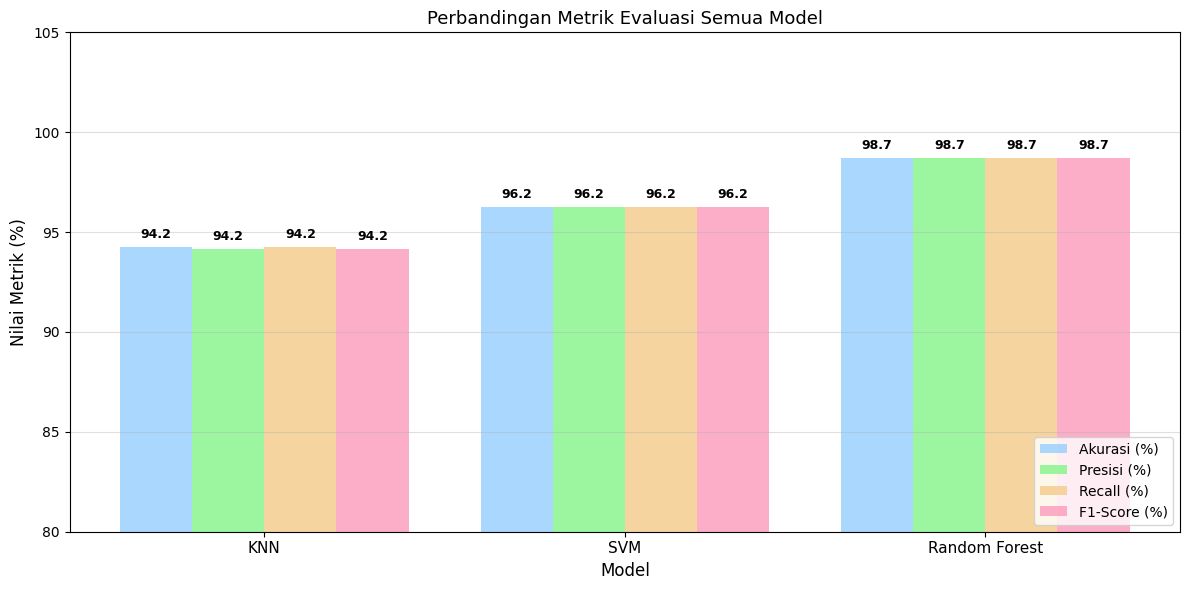

In [34]:
# Grafik perbandingan metrik
hasil_plot = hasil_df.reset_index()
metrik_cols = ['Akurasi (%)', 'Presisi (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(hasil_plot))
width = 0.2
colors_bar = ["#9BD1FD", "#8BF58F", "#F5CD90", "#FC9FBE"] 


fig, ax = plt.subplots(figsize=(12, 6))
for i, (col, color) in enumerate(zip(metrik_cols, colors_bar)):
    bars = ax.bar(x + i * width, hasil_plot[col], width,
                  label=col, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 0.3,
                f"{bar.get_height():.1f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Nilai Metrik (%)', fontsize=12)
ax.set_title('Perbandingan Metrik Evaluasi Semua Model', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(hasil_plot['Model'], fontsize=11)
ax.set_ylim(80, 105)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [35]:
trained_models = {
    'KNN' : (knn, y_pred_knn),
    'SVM' : (svm, y_pred_svm),
    'Random Forest' : (rf, y_pred_rf)
}

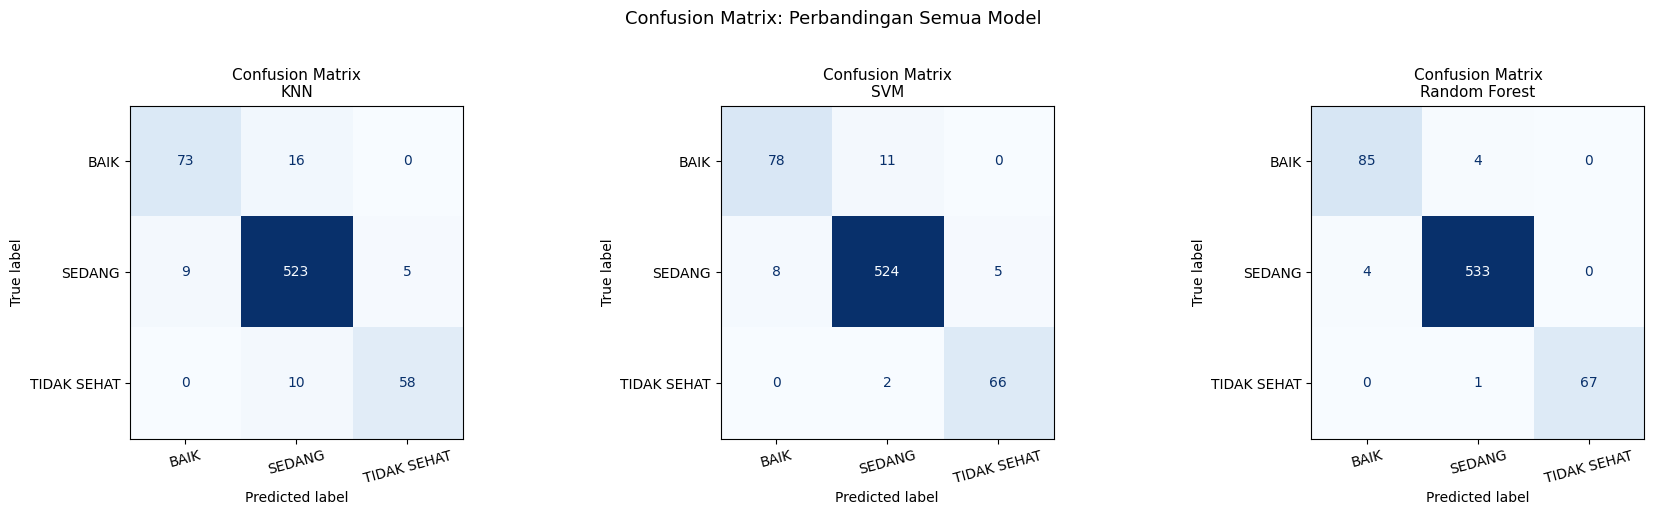

In [36]:
# Confusion Matrix untuk setiap model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nama, (model, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix\n{nama}', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrix: Perbandingan Semua Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Penyimpanan Model dengan Joblib

In [ ]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

best_rf_model = grid_rf.best_estimator_
joblib.dump(best_rf_model, 'saved_models/best_random_forest_model.pkl')
print("Model Random Forest terbaik telah disimpan")

joblib.dump(grid_knn.best_estimator_, 'saved_models/best_knn_model.pkl')
joblib.dump(grid_svm.best_estimator_, 'saved_models/best_svm_model.pkl')
print("Model KNN dan SVM terbaik telah disimpan")

joblib.dump(scaler, 'saved_models/scaler.pkl')
print("Scaler telah disimpan")

joblib.dump(le, 'saved_models/label_encoder.pkl')
print("Label Encoder telah disimpan")

joblib.dump(hasil_df, 'saved_models/hasil_evaluasi_model.pkl')
print("Hasil evaluasi telah disimpan")

print("Verifikasi Load model")
loaded_rf = joblib.load('saved_models/best_random_forest_model.pkl')
loaded_scaler = joblib.load('saved_models/scaler.pkl')
loaded_le = joblib.load('saved_models/label_encoder.pkl')
print("Model berhasil dimuat")





Model Random Forest terbaik telah disimpan
Model KNN dan SVM terbaik telah disimpan
Scaler telah disimpan
Label Encoder telah disimpan
Hasil evaluasi telah disimpan
Verifikasi Load model
Model berhasil dimuat
